<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/STL_to_MSH_to_STEP_using_Gmsh_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
# Execute these system commands in a Colab cell prior to running the Python script
!apt-get update && apt-get install -y -q libgl1 libglu1-mesa
!uv pip install -q gmsh

Upload desired STL file to the general directory, which is on the panel in Google Colab. The next script will scan for any uploaded STL file for conversion to a downloadable mesh and a STEP file.

See reference image below.

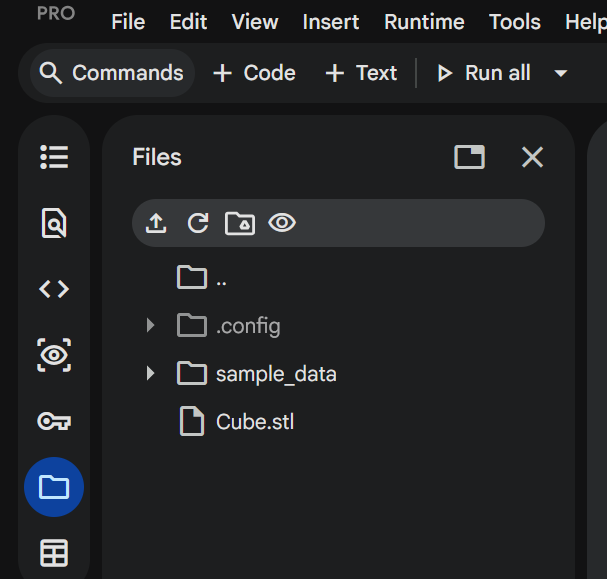

In [6]:
"""
This module scans the local directory for discrete Stereolithography (STL) files,
extracts their spatial dimensions, dynamically reconstructs an equivalent
analytical solid using the OpenCASCADE kernel, applies a structured
quadrilateral grid, and exports both the discrete mesh and the continuous
Standard for the Exchange of Product model data file.
"""
import glob
import os
import gmsh

# === Control Knobs ===
ELEMENT_SIZE = 0.50
RECOMBINE_ALL = 1
ALGORITHM_2D = 8
SUBDIVISION_ALGO = 1
MSH_VERSION = 2.2
# =====================

def process_and_reconstruct_geometries() -> None:
    """
    Iterates through available STL files, extracts boundary dimensions,
    generates continuous OpenCASCADE geometries, and exports dual formats.
    """
    target_files = glob.glob("*.stl")

    if not target_files:
        print("No compatible geometry files detected in the active directory.")
        return

    gmsh.initialize()

    for file_path in target_files:
        print(f"Analyzing and reconstructing geometry: {file_path}")

        base_name = os.path.splitext(file_path)[0]
        output_msh = f"{base_name}_Quads.msh"
        output_step = f"{base_name}_Analytical.step"

        # Load the discrete shell to extract spatial coordinates
        gmsh.clear()
        gmsh.merge(file_path)

        # Extract the global bounding box from the imported discrete entities
        xmin, ymin, zmin, xmax, ymax, zmax = gmsh.model.getBoundingBox(-1, -1)

        # Calculate the precise analytical dimensions
        delta_x = xmax - xmin
        delta_y = ymax - ymin
        delta_z = zmax - zmin

        # Purge the discrete STL geometry from the computational kernel
        gmsh.clear()

        # Reconstruct an exact continuous mathematical solid
        gmsh.model.occ.addBox(xmin, ymin, zmin, delta_x, delta_y, delta_z)
        gmsh.model.occ.synchronize()

        # Apply global mesh option parameters for square cell generation
        gmsh.option.setNumber("Mesh.RecombineAll", RECOMBINE_ALL)
        gmsh.option.setNumber("Mesh.Algorithm", ALGORITHM_2D)
        gmsh.option.setNumber("Mesh.SubdivisionAlgorithm", SUBDIVISION_ALGO)
        gmsh.option.setNumber("Mesh.CharacteristicLengthMin", ELEMENT_SIZE)
        gmsh.option.setNumber("Mesh.CharacteristicLengthMax", ELEMENT_SIZE)
        gmsh.option.setNumber("Mesh.MshFileVersion", MSH_VERSION)

        # Generate the purely quadrilateral surface mesh
        gmsh.model.mesh.generate(2)

        # Export both the discrete grid and the continuous analytical solid
        gmsh.write(output_msh)
        gmsh.write(output_step)

    gmsh.finalize()
    print("Sequential reconstruction and batch processing complete.")

if __name__ == "__main__":
    process_and_reconstruct_geometries()

Analyzing and reconstructing geometry: Cube.stl
Sequential reconstruction and batch processing complete.
